# **1. Setting Up And Getting Data**

1.1 Installing Dependencies

In [ ]:
!pip install labelme tensorflow opencv-python matplotlib

1.2 Collect Images Using OpenCV

In [ ]:
import os
import time
import uuid
import cv2

In [ ]:
IMAGES_PATH = os.path.join('data','images')
number_images = 30

In [ ]:
#cap = cv2.VideoCapture('WIN_20240702_13_10_06_Pro.mp4') #Establishing a connection to our video camera
cap = cv2.VideoCapture(0)
# Check if the video capture is open
if not cap.isOpened():
    print("Error: Could not open video file.")
    exit()
for i in range(number_images):
    print('Collecting image {}'.format(i))
    ret, frame = cap.read() # Read a frame from the video
        # Check if the video is over
    if not ret:
        print("Video playback ended.")
        break
    #save the image as a frame
    imgname = os.path.join(IMAGES_PATH, f'{str(uuid.uuid1())}.jpg')
    cv2.imwrite(imgname, frame)
    cv2.imshow('frame',frame)
    time.sleep(3)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the capture and close all windows
cap.release()
cv2.destroyAllWindows()

1.3 Annotate Images with LabelMe

In [ ]:
!labelme

2024-07-02 19:25:01,660 [INFO   ] __init__:get_config:67- Loading config file from: C:\Users\FAAAST 4\.labelmerc


# **2. Review Dataset And Build Image Loading Function**

2.1 Import TF And Dep

In [2]:
import tensorflow as tf
import cv2
import numpy as np
from matplotlib import pyplot as plt

2.2 Limit GPU Memory Growth

In [3]:
# Preventing Out-of-Memory Errors and for efficient memory usage
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

2.3 Load Image Into TF Data Pipeline

In [ ]:
images = tf.data.Dataset.list_files('data\\images\\*.jpg', shuffle=False)

In [ ]:
# Create an iterator for the dataset
iterator = images.as_numpy_iterator()

# Get the next item from the iterator
next_image = iterator.next()

print(next_image)

b'data\\images\\00fb6a75-3862-11ef-a0ff-f09e4a2d343e.jpg'


In [4]:
def loadImage(x):
    byte_img = tf.io.read_file(x)
    img = tf.io.decode_jpeg(byte_img)
    return img


In [ ]:
#The map function takes a function as an argument and applies this function to each element in the dataset
images = images.map(loadImage)

In [ ]:
images.as_numpy_iterator().next()

array([[[248, 252, 251],
        [247, 251, 250],
        [246, 252, 250],
        ...,
        [235, 252, 246],
        [233, 252, 248],
        [233, 252, 248]],

       [[247, 251, 250],
        [247, 251, 250],
        [246, 252, 250],
        ...,
        [235, 252, 246],
        [234, 253, 249],
        [235, 254, 250]],

       [[247, 251, 250],
        [247, 251, 250],
        [246, 252, 250],
        ...,
        [234, 253, 247],
        [236, 255, 249],
        [237, 255, 250]],

       ...,

       [[ 65,  60,  67],
        [ 59,  54,  61],
        [ 57,  52,  59],
        ...,
        [143, 183, 182],
        [139, 178, 177],
        [138, 177, 176]],

       [[ 50,  40,  49],
        [ 56,  46,  55],
        [ 55,  48,  56],
        ...,
        [144, 183, 182],
        [144, 180, 180],
        [141, 177, 177]],

       [[ 55,  43,  53],
        [ 57,  45,  55],
        [ 60,  50,  59],
        ...,
        [138, 177, 176],
        [141, 177, 177],
        [140, 176, 176]]

In [ ]:
type(images)

tensorflow.python.data.ops.map_op._MapDataset

A TensorFlow data pipeline is a series of steps to preprocess and feed data into a machine learning model efficiently. It is designed to handle large datasets and perform data loading, transformation, augmentation, and batching in a streamlined and scalable manner. TensorFlow provides the tf.data API to build such pipelines, which can handle complex data processing tasks with ease.

2.4 View Raw Images With Matplotlib

In [ ]:
# Batch the dataset
batched_images = images.batch(4)

# Create an iterator
image_generator = batched_images.as_numpy_iterator()

In [ ]:
plot_images = image_generator.next()

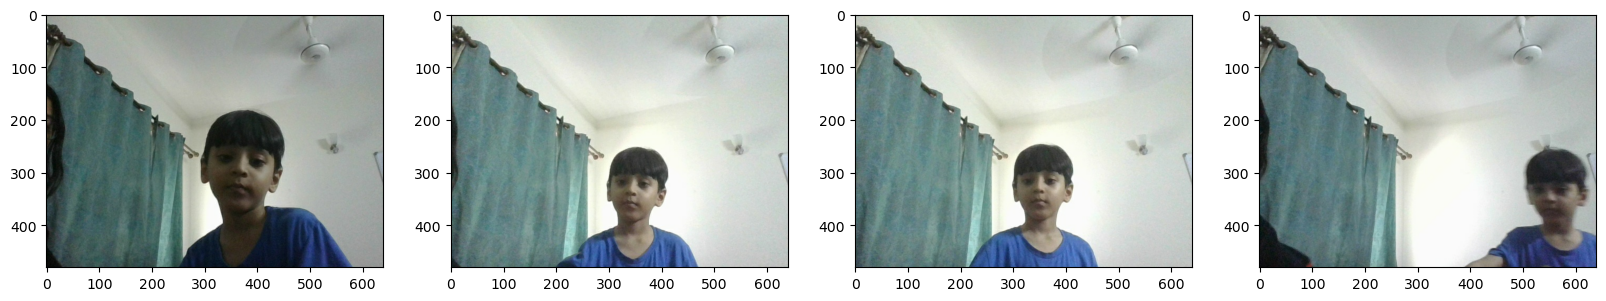

In [ ]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, image in enumerate(plot_images):
    ax[idx].imshow(image)
plt.show()

# **3. Partition Unaugmented Data**

3.1 Manually Split Data Into Train, Val and Test

In [ ]:
104*.7  # 73 images into train

72.8

In [ ]:
104*.15 # 16 images in test and 15 images in val

15.6

In [ ]:
73+16+15

104

3.2 Moving the Matching Labels

In [ ]:
for folder in ['train','test','val']:
    for file in os.listdir(os.path.join('data', folder, 'images')):

        filename = file.split('.')[0]+'.json'
        existing_filepath = os.path.join('data','labels', filename)
        if os.path.exists(existing_filepath):
            new_filepath = os.path.join('data',folder,'labels',filename)
            os.replace(existing_filepath, new_filepath)

# **4. Apply Image Augmentation on Images and Labels Using Albumentations**

4.1 Setup Albumentations Transform Pipeline

In [ ]:
# Install albumentations if not already installed
!pip install --user albumentations

# Check installed packages to verify albumentations
!pip list


  Using cached albumentations-1.4.10-py3-none-any.whl.metadata (38 kB)
  Using cached pydantic-2.8.0-py3-none-any.whl.metadata (123 kB)
  Using cached albucore-0.0.12-py3-none-any.whl.metadata (3.1 kB)
  Using cached opencv_python_headless-4.10.0.84-cp37-abi3-win_amd64.whl.metadata (20 kB)
Using cached albumentations-1.4.10-py3-none-any.whl (161 kB)
Using cached albucore-0.0.12-py3-none-any.whl (8.4 kB)
Using cached opencv_python_headless-4.10.0.84-cp37-abi3-win_amd64.whl (38.8 MB)
Using cached pydantic-2.8.0-py3-none-any.whl (423 kB)
Package                           Version
--------------------------------- ------------------
absl-py                           2.1.0
aiobotocore                       2.12.3
aiohttp                           3.9.5
aioitertools                      0.7.1
aiosignal                         1.2.0
alabaster                         0.7.16
albucore                          0.0.12
albumentations                    1.4.10
altair                            5.0.1


In [ ]:
import albumentations as alb

In [ ]:
# Example path (adjust according to your file structure)
image_path = 'data/train/images/00fb6a75-3862-11ef-a0ff-f09e4a2d343e.jpg'

# Read the image
img = cv2.imread(image_path)

In [ ]:
img.shape

(480, 640, 3)

In [ ]:
type(img)

numpy.ndarray

In [ ]:
augmentor = alb.Compose([alb.RandomCrop(width= 450, height= 450),
                         alb.HorizontalFlip(p=0.5),
                         alb.RandomBrightnessContrast(p=0.2),
                         alb.RandomGamma(p=0.2),
                        alb.RGBShift(p=0.2),
                         alb.VerticalFlip(p=0.5)],
                        bbox_params=alb.BboxParams(format='albumentations', label_fields=['class_labels']))

4.2 Load a Test Image And Annotation With OpenCV And JSON

In [ ]:
# Example path (adjust according to your file structure)
image_path = 'data/train/images/09f5995c-3862-11ef-be16-f09e4a2d343e.jpg'

# Read the image
img = cv2.imread(image_path)

In [ ]:
img.shape

(480, 640, 3)

In [ ]:
import json  # Import the json module

with open(os.path.join('data','train','labels','09f5995c-3862-11ef-be16-f09e4a2d343e.json'), 'r') as f:
    label = json.load(f)


In [ ]:
label['shapes'][0]['points']

[[262.5287356321839, 119.02298850574715],
 [474.5977011494253, 398.33333333333337]]

4.3 Extract Coordinates and Rescale to Match Image Resolution

In [ ]:
coords = [0,0,0,0]
coords[0] =  label['shapes'][0]['points'][0][0]
coords[1] =  label['shapes'][0]['points'][0][1]
coords[2] =  label['shapes'][0]['points'][1][0]
coords[3] =  label['shapes'][0]['points'][1][1]

In [ ]:
coords

[262.5287356321839, 119.02298850574715, 474.5977011494253, 398.33333333333337]

In [ ]:
coords = list(np.divide(coords, [640,480,640,480]))

In [ ]:
coords

[0.41020114942528735,
 0.24796455938697323,
 0.741558908045977,
 0.8298611111111112]

4.4 Apply Augmentation And View Results

In [ ]:
augmented = augmentor(image=img, bboxes=[coords], class_labels=['face'])

In [ ]:
augmented['bboxes'][0][2:]

(0.7435504469987229, 0.8407407407407408)

In [ ]:
augmented['bboxes']

[(0.27228607918263087,
  0.220051085568327,
  0.7435504469987229,
  0.8407407407407408)]

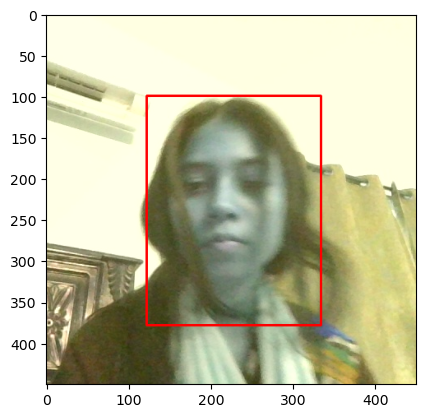

In [ ]:
cv2.rectangle(augmented['image'],
              tuple(np.multiply(augmented['bboxes'][0][:2], [450,450]).astype(int)),
              tuple(np.multiply(augmented['bboxes'][0][2:], [450,450]).astype(int)),
                    (255,0,0), 2)

plt.imshow(augmented['image'])

# **5. Build And Run Augmentation PipeLine**

5.1 Run Augmentation Pipeline

In [ ]:
# Loop over the partitions: train, test, and val
for partition in ['train', 'test', 'val']:
    # Loop over each image in the images directory of the current partition
    for image in os.listdir(os.path.join('data', partition, 'images')):
        # Read the image using OpenCV
        img = cv2.imread(os.path.join('data', partition, 'images', image))

        # Initialize default coordinates (in case there is no label)
        coords = [0, 0, 0.00001, 0.00001]
        # Construct the path to the corresponding label file
        label_path = os.path.join('data', partition, 'labels', f'{image.split(".")[0]}.json')

        # Check if the label file exists
        if os.path.exists(label_path):
            # Open and load the label file
            with open(label_path, 'r') as f:
                label = json.load(f)

            # Extract the coordinates of the bounding box from the label file
            coords[0] = label['shapes'][0]['points'][0][0]
            coords[1] = label['shapes'][0]['points'][0][1]
            coords[2] = label['shapes'][0]['points'][1][0]
            coords[3] = label['shapes'][0]['points'][1][1]
            # Normalize the coordinates based on the image dimensions
            coords = list(np.divide(coords, [640, 480, 640, 480]))

        try:
            # Generate augmented images and labels
            for x in range(60):
                # Apply augmentation to the image and bounding box
                augmented = augmentor(image=img, bboxes=[coords], class_labels=['face'])
                # Save the augmented image
                cv2.imwrite(os.path.join('aug_data', partition, 'images', f'{image.split(".")[0]}.{x}.jpg'), augmented['image'])

                # Prepare the annotation dictionary for the augmented image
                annotation = {}
                annotation['image'] = image

                if os.path.exists(label_path):
                    # If the bounding box is empty after augmentation
                    if len(augmented['bboxes']) == 0:
                        annotation['bbox'] = [0, 0, 0, 0]
                        annotation['class'] = 0  # No face detected
                    else:
                        # Use the augmented bounding box
                        annotation['bbox'] = augmented['bboxes'][0]
                        annotation['class'] = 1  # Face detected
                else:
                    annotation['bbox'] = [0, 0, 0, 0]
                    annotation['class'] = 0  # No label, no face detected

                # Save the annotation to a JSON file
                with open(os.path.join('aug_data', partition, 'labels', f'{image.split(".")[0]}.{x}.json'), 'w') as f:
                    json.dump(annotation, f)

        except Exception as e:
            # Print any exceptions that occur during the process
            print(e)


y_max is less than or equal to y_min for bbox [0.7716503267973855, 0.9936002178649237, 0.9340277777777779, 0.9690904139433552, 'face'].


5.2 Load Augmented Images to Tensorflow Dataset

In [10]:
train_images = tf.data.Dataset.list_files('aug_data\\train\\images\\*.jpg', shuffle=False)
train_images = train_images.map(loadImage)
train_images = train_images.map(lambda x: tf.image.resize(x, (120,120)))
train_images = train_images.map(lambda x: x/255)

In [11]:
test_images = tf.data.Dataset.list_files('aug_data\\test\\images\\*.jpg', shuffle=False)
test_images = test_images.map(loadImage)
test_images = test_images.map(lambda x: tf.image.resize(x, (120,120)))
test_images = test_images.map(lambda x: x/255)

In [12]:
val_images = tf.data.Dataset.list_files('aug_data\\val\\images\\*.jpg', shuffle=False)
val_images = val_images.map(loadImage)
val_images = val_images.map(lambda x: tf.image.resize(x, (120,120)))
val_images = val_images.map(lambda x: x/255)

In [ ]:
train_images.as_numpy_iterator().next()

array([[[0.9979779 , 0.9608456 , 0.94215685],
        [0.9481005 , 0.90085787, 0.86311275],
        [0.861826  , 0.7956495 , 0.7191789 ],
        ...,
        [0.4120098 , 0.38229167, 0.43523285],
        [0.4186887 , 0.3602941 , 0.42408088],
        [0.41084558, 0.3721201 , 0.4319853 ]],

       [[0.99491423, 0.9612745 , 0.9474265 ],
        [0.95870095, 0.9180147 , 0.8827206 ],
        [0.88443625, 0.83345586, 0.7599878 ],
        ...,
        [0.4090686 , 0.37965685, 0.4501838 ],
        [0.42530638, 0.39375   , 0.44577205],
        [0.4107843 , 0.4120098 , 0.436826  ]],

       [[1.        , 0.9481618 , 0.94099265],
        [0.9705882 , 0.9191176 , 0.8872549 ],
        [0.8918505 , 0.83253676, 0.75349265],
        ...,
        [0.3166054 , 0.26997548, 0.3471201 ],
        [0.3194853 , 0.28664216, 0.33909315],
        [0.29031864, 0.27818626, 0.30159312]],

       ...,

       [[0.9436275 , 0.9632353 , 0.9867647 ],
        [0.9268995 , 0.9543505 , 0.9778799 ],
        [0.92941177, 0

# **6. Prepare Labels**

6.1 Build Label Loading Function

In [5]:
import json

def load_labels(label_path):
    """
    Load labels and bounding boxes from a JSON file.

    Args:
        label_path (str): The path to the label JSON file.

    Returns:
        tuple: A tuple containing:
            - A list with the class label.
            - The bounding box coordinates.
    """
    try:
        # Convert the tensor to a string if it isn't already
        if isinstance(label_path, tf.Tensor):
            label_path = label_path.numpy().decode('utf-8')

        # Open the label file in read mode with UTF-8 encoding
        with open(label_path, 'r', encoding='utf-8') as f:
            # Load the JSON data from the file
            label = json.load(f)

        # Check if 'class' and 'bbox' keys exist in the label data
        if 'class' not in label:
            raise KeyError(f"Missing 'class' key in the label file: {label_path}")
        if 'bbox' not in label:
            raise KeyError(f"Missing 'bbox' key in the label file: {label_path}")

        # Extract the class label and bounding box from the JSON data
        return [label['class']], label['bbox']

    except Exception as e:
        print(f"Error loading label file {label_path}: {e}")
        return [0], [0, 0, 0, 0]  # Return default values in case of error


6.2 Load Labels to Tensorflow DataSet

tf.py_function is used to wrap a Python function (load_labels) and make it usable within a TensorFlow computation graph.
The first argument to tf.py_function is the Python function to be wrapped (load_labels).
The second argument is a list of inputs to the function ([x]). Here, x is the input element from the dataset.
The third argument is a list of output data types ([tf.uint8, tf.float16]). These types should match the return types of the load_labels function.

In [6]:
train_labels = tf.data.Dataset.list_files('aug_data\\train\\labels\\*.json', shuffle=False)
train_labels = train_labels.map(lambda x: tf.py_function(load_labels, [x], [tf.uint8, tf.float16]))

In [7]:
test_labels = tf.data.Dataset.list_files('aug_data\\test\\labels\\*.json', shuffle=False)
test_labels = test_labels.map(lambda x: tf.py_function(load_labels, [x], [tf.uint8, tf.float16]))

In [8]:
val_labels = tf.data.Dataset.list_files('aug_data\\val\\labels\\*.json', shuffle=False)
val_labels = val_labels.map(lambda x: tf.py_function(load_labels, [x], [tf.uint8, tf.float16]))

In [ ]:
train_labels.as_numpy_iterator().next()

(array([1], dtype=uint8),
 array([0.    , 0.1835, 0.3357, 0.6333], dtype=float16))

# **7. Combine Label and Image Samples**

7.1 Check Partition Lengths

In [13]:
len(train_images), len(train_labels), len(test_images), len(test_labels), len(val_images), len(val_labels)

(4320, 4320, 960, 960, 900, 900)

7.2 Create Final Datasets (Images/Labels)

In [14]:
def set_shapes(image, classes, bboxes):
    image.set_shape([120, 120, 3])  # Assuming images are RGB with shape (120, 120, 3)
    classes.set_shape([1])  # Shape of classes (1)
    bboxes.set_shape([4])  # Shape of bboxes (4)
    return image, (classes, bboxes)

# Assuming train_images and train_labels are TensorFlow datasets or compatible iterables
train = tf.data.Dataset.zip((train_images, train_labels))

# Apply set_shapes function after zipping
train = train.map(lambda img, lbl: set_shapes(img, lbl[0], lbl[1]))

# Shuffle and batch the dataset
train = train.shuffle(5000)
train = train.batch(8)

# Prefetch data for better performance
train = train.prefetch(4)


In [15]:
# Assuming val_images and val_labels are TensorFlow datasets or compatible iterables
val = tf.data.Dataset.zip((val_images, val_labels))

# Apply set_shapes function after zipping
val = val.map(lambda img, lbl: set_shapes(img, lbl[0], lbl[1]))

# Shuffle and batch the dataset (if needed for validation)
val = val.shuffle(1000)
val = val.batch(8)

# Prefetch data for better performance
val = val.prefetch(4)

In [16]:
# Assuming test_images and test_labels are TensorFlow datasets or compatible iterables
test = tf.data.Dataset.zip((test_images, test_labels))

# Function to set shapes for images, classes, and bboxes (assuming similar to validation)
def set_shapes(image, classes, bboxes):
    image.set_shape([120, 120, 3])  # Assuming images are RGB with shape (120, 120, 3)
    classes.set_shape([1])  # Shape of classes (1)
    bboxes.set_shape([4])  # Shape of bboxes (4)
    return image, (classes, bboxes)

# Apply set_shapes function after zipping
test = test.map(lambda img, lbl: set_shapes(img, lbl[0], lbl[1]))

# Shuffle and batch the dataset (if needed for test)
test = test.shuffle(1000)
test = test.batch(8)

# Prefetch data for better performance
test = test.prefetch(4)


In [ ]:
train.as_numpy_iterator().next()[1]

(array([[1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1]], dtype=uint8),
 array([[0.     , 0.3464 , 0.1664 , 0.8574 ],
        [0.07697, 0.4395 , 0.441  , 0.9097 ],
        [0.283  , 0.2048 , 0.669  , 0.75   ],
        [0.804  , 0.1101 , 1.     , 0.4766 ],
        [0.3223 , 0.3728 , 0.681  , 0.8545 ],
        [0.8423 , 0.357  , 1.     , 0.745  ],
        [0.3298 , 0.1323 , 0.663  , 0.545  ],
        [0.506  , 0.2067 , 0.9194 , 0.738  ]], dtype=float16))

7.3 View Images and Annotations

In [ ]:
data_samples = train.as_numpy_iterator()

In [ ]:
res = data_samples.next()

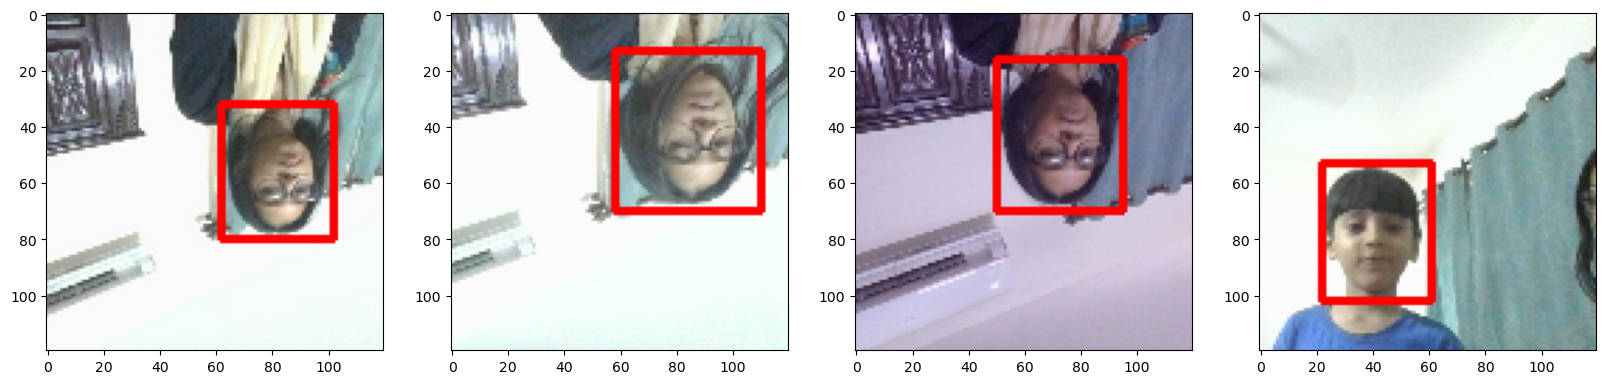

In [ ]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4):
    sample_image = res[0][idx].copy()  # Create a modifiable copy of the image
    sample_coords = res[1][1][idx]

    cv2.rectangle(sample_image,
                  tuple(np.multiply(sample_coords[:2], [120,120]).astype(int)),
                  tuple(np.multiply(sample_coords[2:], [120,120]).astype(int)),
                        (255,0,0), 2)

    ax[idx].imshow(sample_image)

# **8. Build Deep Learning Using The Functional API**

8.1 Import Layers and Base Network

In [17]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, GlobalMaxPooling2D, Dense
from tensorflow.keras.applications import VGG16

8.2 Download VGG16

In [18]:
vgg = VGG16(include_top = False) #include_top indicates do not include the final classification layers

In [19]:
vgg.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, None, None, 3)       │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, None, None, 64)      │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, None, None, 64)      │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, None, None, 64)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, None, None, 128)     │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, None, None, 128)     │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, None, None, 128)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, None, None, 256)     │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, None, None, 256)     │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, None, None, 256)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, None, None, 512)     │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, None, None, 512)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, None, None, 512)     │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, None, None, 512)     │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

8.3 Build Instance Of Network

In [20]:
def build_model():
  input_layer = Input(shape=(120,120,3))

  vgg = VGG16(include_top = False)(input_layer)

  # Classification Model
  f1 = GlobalMaxPooling2D()(vgg)
  class1 = Dense(2048, activation='relu')(f1)
  class2 = Dense(1, activation='sigmoid')(class1)

  # Bounding Box Model
  f2 = GlobalMaxPooling2D()(vgg)
  regress1 = Dense(2048, activation='relu')(f2)
  regress2 = Dense(4, activation='sigmoid')(regress1)

  facetracker = Model(input_layer, [class2, regress2])
  return facetracker


8.4 Test out Neural Network

In [21]:
face_tracker = build_model()

In [22]:
face_tracker.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 120, 120, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ vgg16 (Functional)            │ (None, 3, 3, 512)         │      14,714,688 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling2d          │ (None, 512)               │               0 │ vgg16[0][0]                │
│ (GlobalMaxPooling2D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling2d_1        │ (None, 512)               │               0 │ vgg16[0][0]                │
│ (GlobalMaxPooling2D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 2048)              │       1,050,624 │ global_max_pooling2d[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 2048)              │       1,050,624 │ global_max_pooling2d_1[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 1)                 │           2,049 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 4)                 │           8,196 │ dense_2[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 16,826,181 (64.19 MB)

 Trainable params: 16,826,181 (64.19 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
X, y = train.as_numpy_iterator().next()

In [24]:
X.shape

(8, 120, 120, 3)

In [ ]:
classes, coords = face_tracker.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 846ms/step


In [ ]:
classes, coords

(array([[0.6289036 ],
        [0.7003608 ],
        [0.65591717],
        [0.7060132 ],
        [0.69787985],
        [0.7087605 ],
        [0.6790945 ],
        [0.62954843]], dtype=float32),
 array([[0.5788856 , 0.6940805 , 0.46749136, 0.48539555],
        [0.50729537, 0.75596505, 0.51250786, 0.42873973],
        [0.43785012, 0.6377666 , 0.47974876, 0.64129424],
        [0.4955922 , 0.6495714 , 0.50605917, 0.62483907],
        [0.4411341 , 0.7224552 , 0.43145275, 0.49957713],
        [0.49047586, 0.74450403, 0.48507982, 0.506397  ],
        [0.40569478, 0.73098385, 0.48125508, 0.46483883],
        [0.42665985, 0.79660535, 0.51453257, 0.4396839 ]], dtype=float32))

# **9. Define Losses and Optimizers**

9.1 Define Optimizer and LR

In [25]:
batches_per_epoch = len(train)
lr_decay = (1./0.75-1)/batches_per_epoch


In [28]:
opt = tf.keras.optimizers.Adam(learning_rate=0.0001,decay=lr_decay)

9.2 Create Localization Loss and Classification Loss

In [27]:
def localization_loss(y_true, y_pred):
  delta_coord = tf.reduce_sum(tf.square(y_true[:,:2] - y_pred[:,:2]))

  h_true = y_true[:,3] - y_true[:,1]
  w_true = y_true[:,2] - y_true[:,0]

  h_pred = y_pred[:,3] - y_pred[:,1]
  w_pred = y_pred[:,2] - y_pred[:,0]

  delta_size = tf.reduce_sum(tf.square(w_true - w_pred) + tf.square(h_true - h_pred))

  return delta_coord + delta_size

In [29]:
classloss = tf.keras.losses.BinaryCrossentropy()
regressloss = localization_loss

9.3 Test out Loss Metrics

In [ ]:
y

(array([[1],
        [1],
        [0],
        [0],
        [1],
        [1],
        [1],
        [1]], dtype=uint8),
 array([[0.7134 , 0.5547 , 1.     , 0.921  ],
        [0.3176 , 0.3372 , 0.707  , 0.868  ],
        [0.     , 0.     , 0.     , 0.     ],
        [0.     , 0.     , 0.     , 0.     ],
        [0.0623 , 0.1904 , 0.4492 , 0.6846 ],
        [0.404  , 0.2578 , 0.713  , 0.6587 ],
        [0.10425, 0.1599 , 0.4287 , 0.543  ],
        [0.3032 , 0.2832 , 0.6777 , 0.798  ]], dtype=float16))

In [ ]:
localization_loss(y[1], coords)

<tf.Tensor: shape=(), dtype=float32, numpy=6.7613254>

In [ ]:
classloss(y[0], classes)

<tf.Tensor: shape=(), dtype=float32, numpy=0.5830904>

In [ ]:
regressloss(y[1], coords)

<tf.Tensor: shape=(), dtype=float32, numpy=6.7613254>

# **10. Train Neural Network**

10.1 Create Custom Model Class

In [ ]:
X, y = train.as_numpy_iterator().next()

In [ ]:
X.shape

(8, 120, 120, 3)

In [ ]:
classes

array([[0.6289036 ],
       [0.7003608 ],
       [0.65591717],
       [0.7060132 ],
       [0.69787985],
       [0.7087605 ],
       [0.6790945 ],
       [0.62954843]], dtype=float32)

In [30]:
class FaceTracker(Model):
    def __init__(self, eyetracker,  **kwargs):
        super().__init__(**kwargs)
        self.model = eyetracker

    def compile(self, opt, classloss, localizationloss, **kwargs):
        super().compile(**kwargs)
        self.closs = classloss
        self.lloss = localizationloss
        self.opt = opt

    def train_step(self, batch, **kwargs):

        X, y = batch

        with tf.GradientTape() as tape:
            classes, coords = self.model(X, training=True)
             # Ensure shapes are set explicitly
            y_true = tf.ensure_shape(y[0], [8, 1])  # Assuming batch size is 8
            classes = tf.ensure_shape(classes, [8, 1])  # Ensure classes have shape (8, 1)
            batch_classloss = self.closs(y[0], classes)
            batch_localizationloss = self.lloss(tf.cast(y[1], tf.float32), coords)

            total_loss = batch_localizationloss+0.5*batch_classloss

            grad = tape.gradient(total_loss, self.model.trainable_variables)

        opt.apply_gradients(zip(grad, self.model.trainable_variables))

        return {"total_loss":total_loss, "class_loss":batch_classloss, "regress_loss":batch_localizationloss}

    def test_step(self, batch, **kwargs):
        X, y = batch
        print("check")

        classes, coords = self.model(X, training=False)

        batch_classloss = self.closs(y[0], classes)
        batch_localizationloss = self.lloss(tf.cast(y[1], tf.float32), coords)
        total_loss = batch_localizationloss+0.5*batch_classloss

        return {"total_loss":total_loss, "class_loss":batch_classloss, "regress_loss":batch_localizationloss}

    def call(self, X, **kwargs):
        return self.model(X, **kwargs)

In [31]:
model = FaceTracker(face_tracker)

In [32]:
model.compile(opt, classloss, regressloss)

10.2 Train

In [33]:
print("Training data shape:", train)
print("Validation data shape:", val)

Training data shape: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 120, 120, 3), dtype=tf.float32, name=None), (TensorSpec(shape=(None, 1), dtype=tf.uint8, name=None), TensorSpec(shape=(None, 4), dtype=tf.float16, name=None)))>
Validation data shape: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 120, 120, 3), dtype=tf.float32, name=None), (TensorSpec(shape=(None, 1), dtype=tf.uint8, name=None), TensorSpec(shape=(None, 4), dtype=tf.float16, name=None)))>


In [34]:
logdir='logs'

In [35]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [36]:
hist = model.fit(train, epochs=10, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - class_loss: 0.0613 - regress_loss: 0.2354 - total_loss: 0.2660check
540/540 ━━━━━━━━━━━━━━━━━━━━ 682s 1s/step - class_loss: 0.0612 - regress_loss: 0.2350 - total_loss: 0.2656 - val_class_loss: 0.0037 - val_regress_loss: 0.0104 - val_total_loss: 0.0122
Epoch 2/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 547s 1s/step - class_loss: 0.0256 - regress_loss: 0.1001 - total_loss: 0.1129 - val_class_loss: 0.0520 - val_regress_loss: 0.0427 - val_total_loss: 0.0687
Epoch 3/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 553s 1s/step - class_loss: 0.0134 - regress_loss: 0.0538 - total_loss: 0.0605 - val_class_loss: 0.0122 - val_regress_loss: 0.0324 - val_total_loss: 0.0385
Epoch 4/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 604s 1s/step - class_loss: 0.0164 - regress_loss: 0.0681 - total_loss: 0.0763 - val_class_loss: 0.0034 - val_regress_loss: 0.0792 - val_total_loss: 0.0809
Epoch 5/10
540/540 ━━━━━━━━━━━━━━━━━━━━ 715s 1s/step - class_loss: 0.0198 - regress_loss: 0.0574 - total_loss:

10.3 Plot Performance

In [37]:
hist.history

{'class_loss': [2.975105235236697e-05,
  0.0010685044107958674,
  0.0011578814592212439,
  0.01015178207308054,
  0.00021745423146057874,
  0.0005868194857612252,
  6.16291508777067e-05,
  6.719495286233723e-05,
  3.28811293002218e-05,
  0.00028318457771092653],
 'regress_loss': [0.029731735587120056,
  0.07439875602722168,
  0.019496586173772812,
  0.04003357142210007,
  0.01603967510163784,
  0.04422689974308014,
  0.011782814748585224,
  0.009817207232117653,
  0.006886260583996773,
  0.004559248685836792],
 'total_loss': [0.029746610671281815,
  0.0749330073595047,
  0.02007552608847618,
  0.04510946199297905,
  0.01614840142428875,
  0.044520311057567596,
  0.011813629418611526,
  0.009850804693996906,
  0.00690270122140646,
  0.004700840916484594],
 'val_class_loss': [0.00365973892621696,
  0.05198989063501358,
  0.012180463410913944,
  0.0033960810396820307,
  0.002266698284074664,
  0.4726525545120239,
  8.986503235064447e-05,
  2.8071113774785772e-05,
  0.6003946661949158,
  0

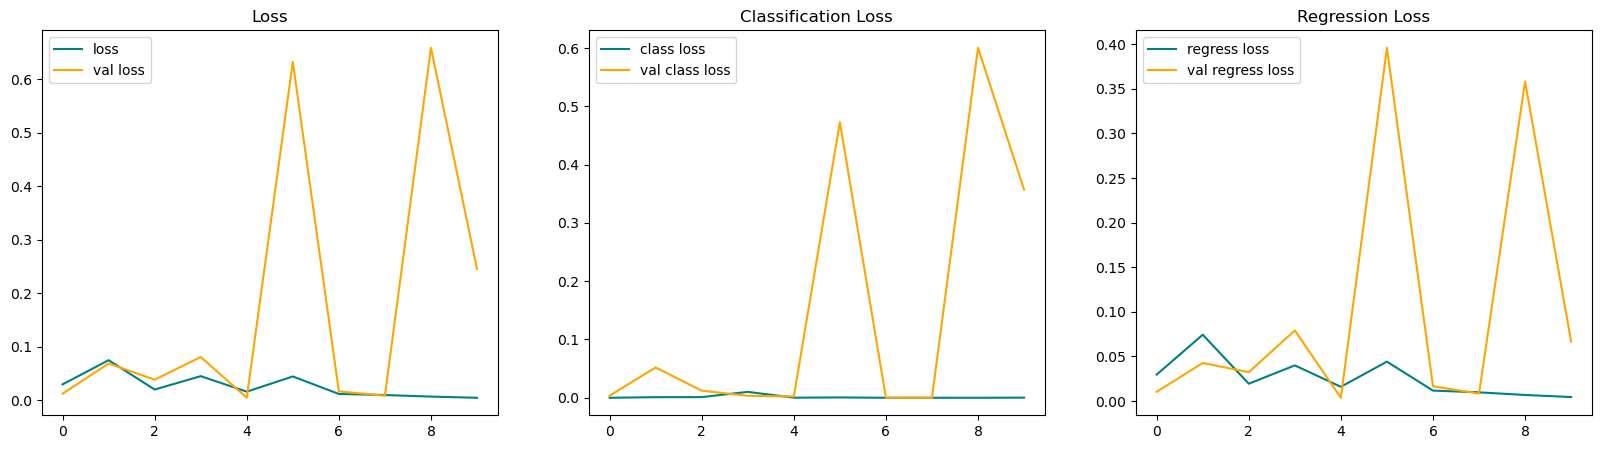

In [38]:
fig, ax = plt.subplots(ncols=3, figsize=(20,5))

ax[0].plot(hist.history['total_loss'], color='teal', label='loss')
ax[0].plot(hist.history['val_total_loss'], color='orange', label='val loss')
ax[0].title.set_text('Loss')
ax[0].legend()

ax[1].plot(hist.history['class_loss'], color='teal', label='class loss')
ax[1].plot(hist.history['val_class_loss'], color='orange', label='val class loss')
ax[1].title.set_text('Classification Loss')
ax[1].legend()

ax[2].plot(hist.history['regress_loss'], color='teal', label='regress loss')
ax[2].plot(hist.history['val_regress_loss'], color='orange', label='val regress loss')
ax[2].title.set_text('Regression Loss')
ax[2].legend()

plt.show()

# **11. Make Predictions**

11.1 Make Predictions on Test Set

In [39]:
test_data = test.as_numpy_iterator()

In [54]:
test_sample = test_data.next()

In [55]:
yhat = face_tracker.predict(test_sample[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


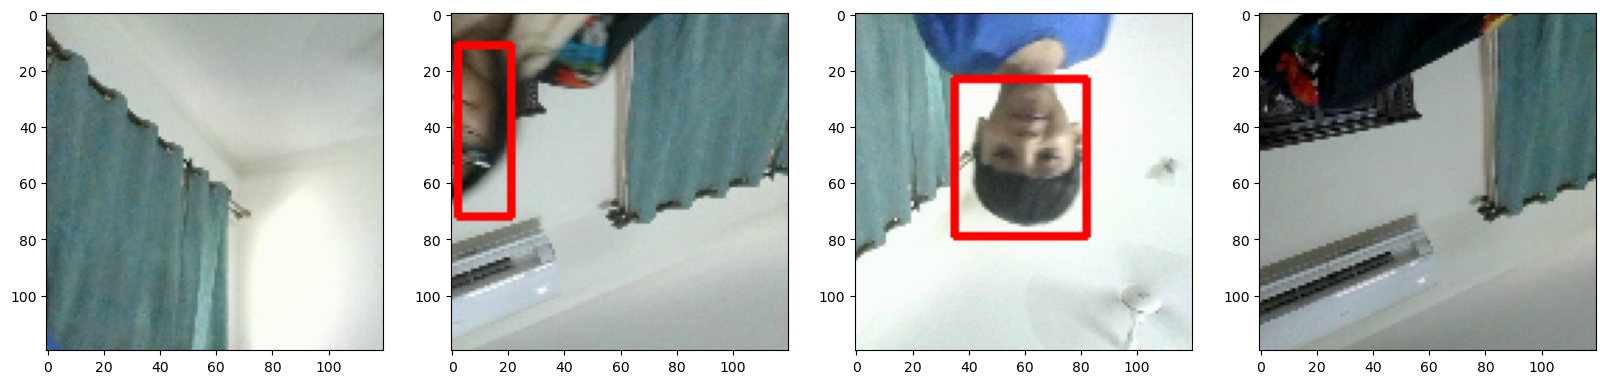

In [56]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx in range(4):
    sample_image = test_sample[0][idx].copy()
    sample_coords = yhat[1][idx]

    if yhat[0][idx] > 0.9:
        cv2.rectangle(sample_image,
                      tuple(np.multiply(sample_coords[:2], [120,120]).astype(int)),
                      tuple(np.multiply(sample_coords[2:], [120,120]).astype(int)),
                            (255,0,0), 2)

    ax[idx].imshow(sample_image)

11.2 Save the Model

In [57]:
from tensorflow.keras.models import load_model

In [61]:
face_tracker.save('facetracker.keras')

In [62]:
face_tracker = load_model('facetracker.keras')

11.3 Real Time Detection

In [64]:
# Open a connection to the video capture device (webcam). The argument '1' might need to be changed to '0' or another value depending on your setup.
cap = cv2.VideoCapture(0)

# Loop until the video capture is open
while cap.isOpened():
    # Read a frame from the video capture
    _, frame = cap.read()

    # Crop the frame to focus on the central region
    frame = frame[50:500, 50:500, :]

    # Convert the frame from BGR to RGB color space
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Resize the RGB frame to the input size expected by the model (120x120)
    resized = tf.image.resize(rgb, (120,120))

    # Make a prediction using the facetracker model
    yhat = face_tracker.predict(np.expand_dims(resized / 255.0, 0))
    sample_coords = yhat[1][0]

    # If the model predicts a face with a confidence greater than 0.5
    if yhat[0] > 0.5:
        # Draw the main rectangle around the detected face
        cv2.rectangle(frame,
                      tuple(np.multiply(sample_coords[:2], [450,450]).astype(int)),
                      tuple(np.multiply(sample_coords[2:], [450,450]).astype(int)),
                      (255,0,0), 2)

        # Draw a filled rectangle for the label background
        cv2.rectangle(frame,
                      tuple(np.add(np.multiply(sample_coords[:2], [450,450]).astype(int), [0, -30])),
                      tuple(np.add(np.multiply(sample_coords[:2], [450,450]).astype(int), [80, 0])),
                      (255,0,0), -1)

        # Render the text 'face' above the detected face
        cv2.putText(frame, 'face',
                    tuple(np.add(np.multiply(sample_coords[:2], [450,450]).astype(int), [0, -5])),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,255), 2, cv2.LINE_AA)

    # Display the frame with the annotations
    cv2.imshow('EyeTrack', frame)

    # Break the loop if the 'q' key is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the video capture and close any OpenCV windows
cap.release()
cv2.destroyAllWindows()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━